<a href="https://www.pieriandata.com"><img src="../DATA/Logo.jpg"></a>
*Copyright Pierian Data Inc.*

# Image Processing Assessment

Complete the tasks in bold below! Feel free to treat this as a code along by skipping this assessment lecture and moving straight to the solutions lecture!

**Some Useful Code is already here for you in the cells below:**

In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [34]:
def display_img(img,cmap=None):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap)

**TASK: Open and display the giaraffes.jpg image that is located in the DATA folder.**

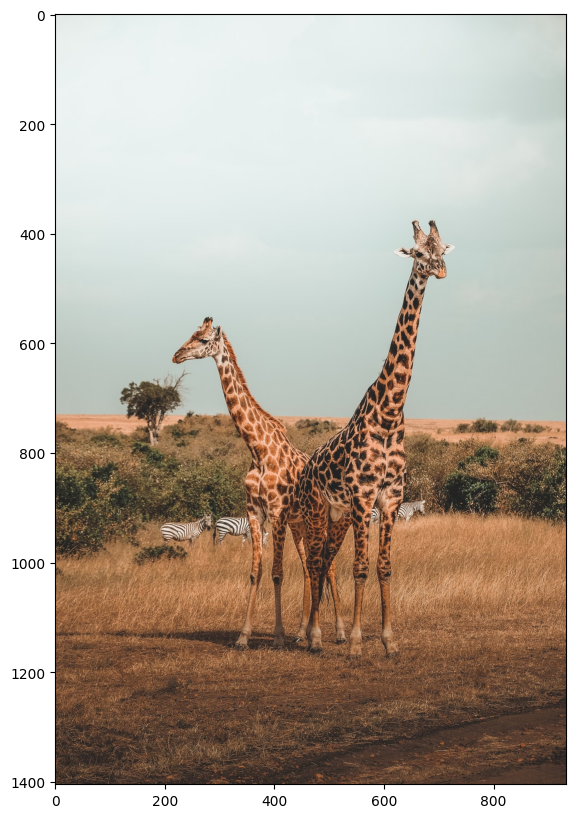

In [35]:
image_path = r"D:\UMEF\E1402_Digital and Computer Vision\session4\image.jpg"
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Could not read image at {image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
display_img(img_rgb)

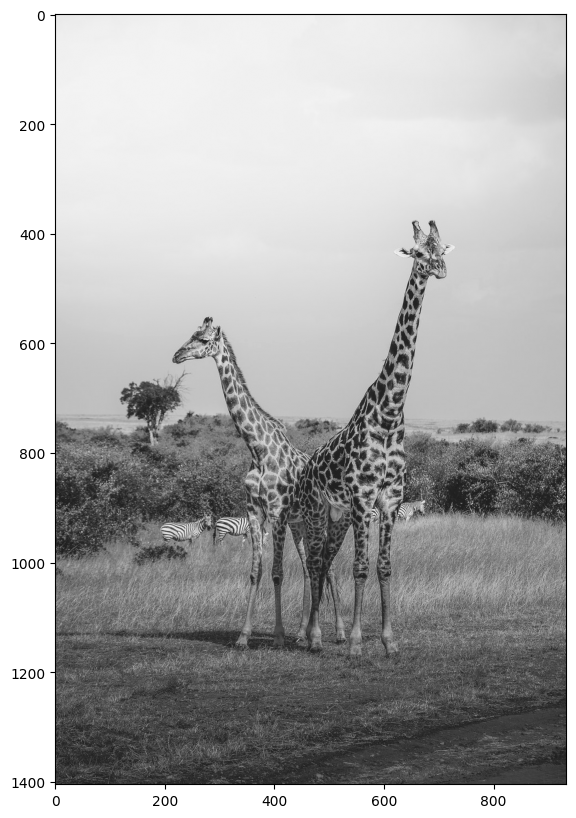

In [36]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
display_img(gray, cmap='gray')

**TASK:Apply a binary threshold onto the image.**

In [37]:
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
ret

127.0

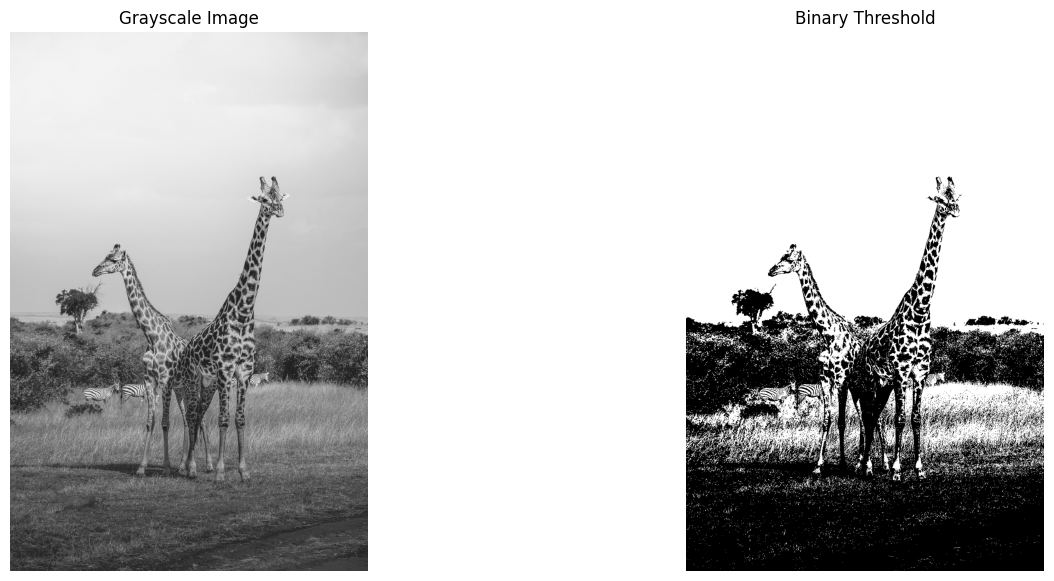

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

axes[1].imshow(thresh, cmap='gray')
axes[1].set_title('Binary Threshold')
axes[1].axis('off')
plt.show()

**TASK: Open the giaraffes.jpg file from the DATA folder and convert its colorspace to  HSV and display the image.**

In [39]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_hsv_display = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

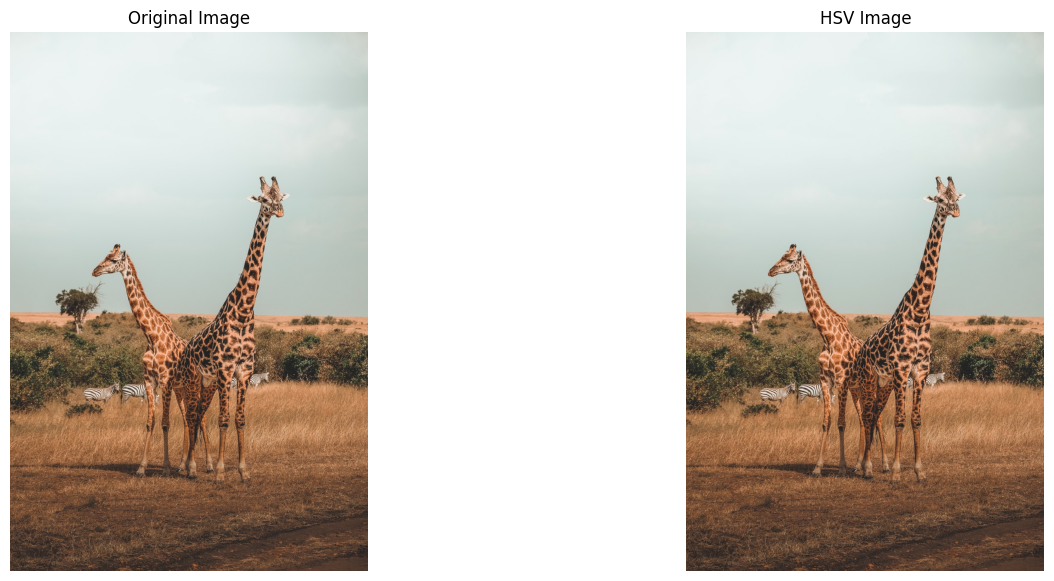

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_hsv_display)
axes[1].set_title('HSV Image')
axes[1].axis('off')
plt.show()

**TASK: Create a low pass filter with a 4 by 4 Kernel filled with values of 1/10 (0.01) and then use 2-D Convolution to blur the giraffer image (displayed in normal RGB)**

In [41]:
kernel = np.ones((4, 4), dtype=np.float32) / 10

In [42]:
blurred = cv2.filter2D(img_rgb, -1, kernel)
blurred

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[134,  99,  76],
        [134,  99,  76],
        [126,  93,  72],
        ...,
        [123,  91,  74],
        [122,  90,  74],
        [123,  92,  76]],

       [[126,  91,  70],
        [126,  91,  70],
        [121,  88,  69],
        ...,
        [122,  90,  74],
        [120,  89,  73],
        [121,  90,  74]],

       [[137, 100,  77],
        [137, 100,  77],
        [132,  97,  76],
        ...,
        [121,  89,  73],
        [119,  88,  73],
        [121,  89,  75]]

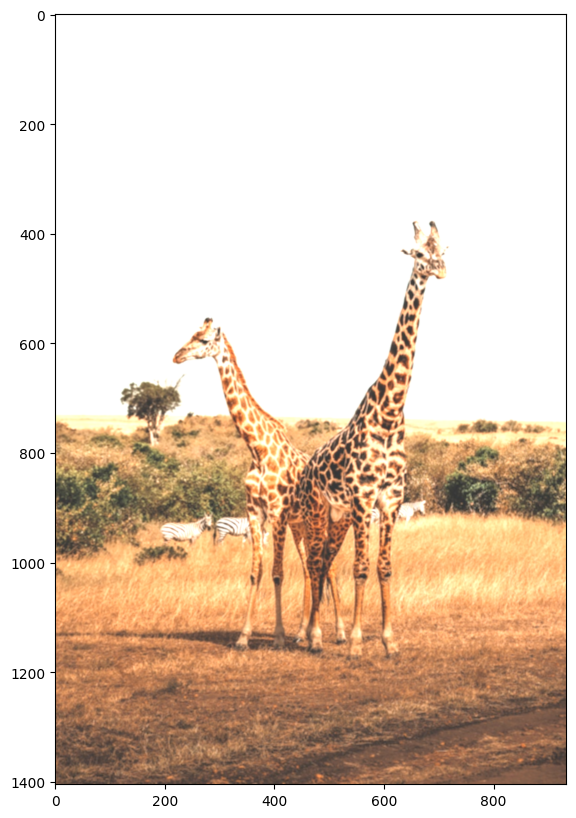

In [43]:
display_img(blurred)

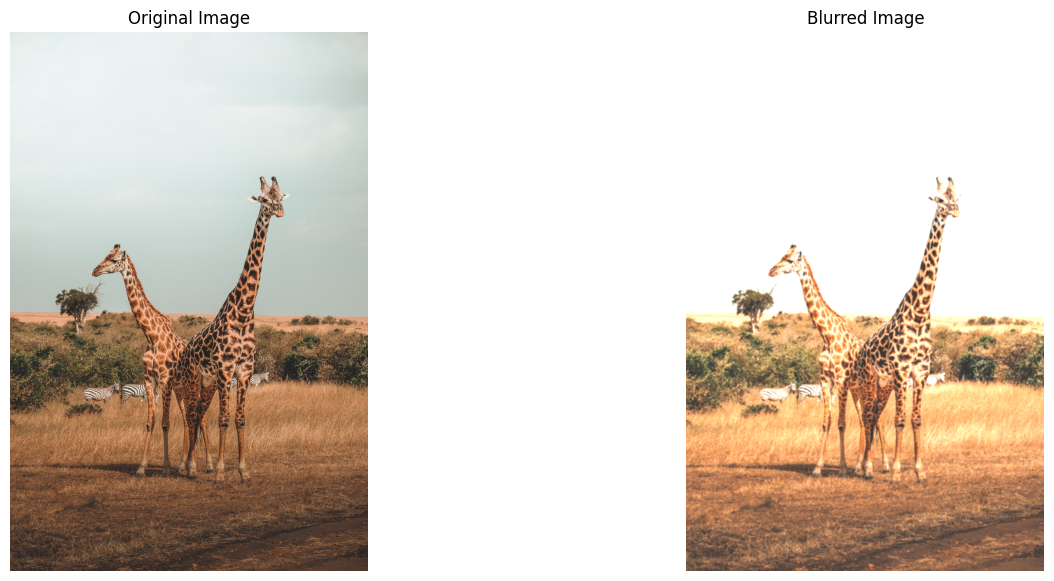

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(blurred)
axes[1].set_title('Blurred Image')
axes[1].axis('off')
plt.show()

**TASK: Create a Horizontal Sobel Filter (sobelx from our lecture) with a kernel size of 5 to the grayscale version of the giaraffes image and then display the resulting gradient filtered version of the image.**

In [45]:
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)

In [46]:
abs_sobelx = np.absolute(sobelx)
scaled_sobelx = np.uint8(255 * abs_sobelx / np.max(abs_sobelx))

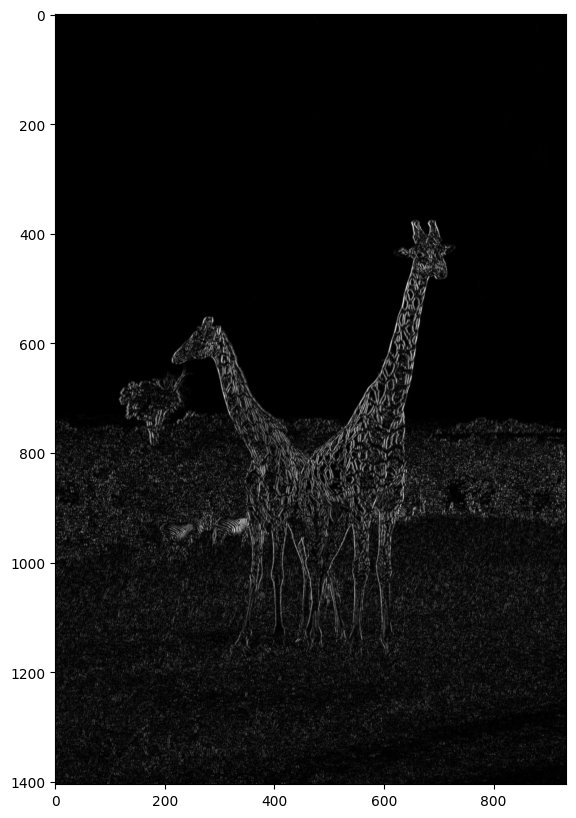

In [47]:
display_img(scaled_sobelx, cmap='gray')

**TASK: Plot the color histograms for the RED, BLUE, and GREEN channel of the giaraffe image. Pay careful attention to the ordering of the channels.**

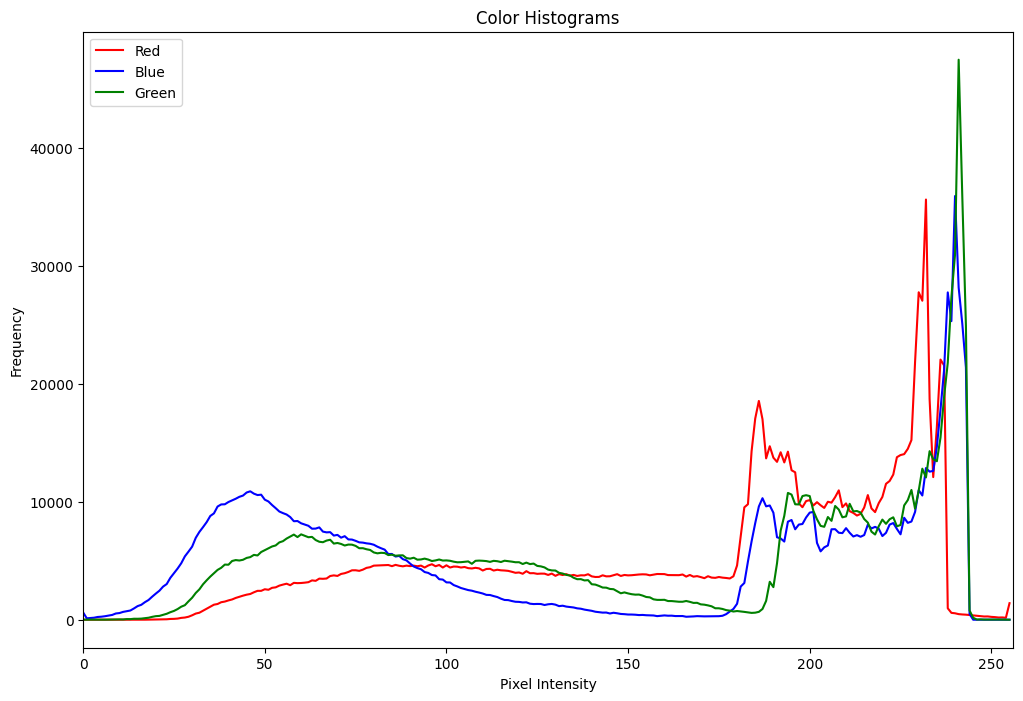

In [48]:
fig = plt.figure(figsize=(12, 8))
for label, channel, color in [('Red', 2, 'r'), ('Blue', 0, 'b'), ('Green', 1, 'g')]:
    hist = cv2.calcHist([img], [channel], None, [256], [0, 256])
    plt.plot(hist, color=color, label=label)

plt.title('Color Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.xlim([0, 256])
plt.show()

# Great job!